In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind

#Создаем DataFrame
duolingo_df = pd.read_csv('/Users/arinarogovets/Yandex.Disk.localized/Школа 21/Datasets /duolingo.csv')

#Находим первые 5 строк
five_strings = duolingo_df.head()

#Выводим количество строк и колонок 2 способ
print("="*70)
print("Размер датасета:")
print("Количество строк:", len(duolingo_df))
print("Количество колонок:", len(duolingo_df.columns))
#Выводим первые пять строк
print("="*70)
print("Первые пять строк следующие:")
print(five_strings)
#Выводим названия и типы данных способ 1 
print("="*70)
print("Названия колонок и типы данных:")
print(duolingo_df.dtypes)
#Проверяем пустые значения
print("="*70)
print("Пустые значения в строках:")
print(duolingo_df.isna().sum())
print("Пропущенных значений нет")
#Задаем группы 
group_a = duolingo_df[duolingo_df['experiment_group'] == 'A']['p_recall_ab']
group_b = duolingo_df[duolingo_df['experiment_group'] == 'B']['p_recall_ab']
#Выводим количество записей в каждой группе 
print("="*70)
print("Количество записей в группе A:", len(group_a))
print("Количество записей в группе B:", len(group_b))
# Проверка баланса групп
print("="*70)
if len(group_a) == len(group_b):
    print("Группы сбалансированы по размеру")
else:
    print("Группы разного размера — это стоит учесть при интерпретации результатов теста")
#Считаем описательную статистику
print("="*70)
def print_stats(experiment_group, p_recall_ab):
    """Выводит статистику для группы"""
    print(f"\n{experiment_group}:")
    print(f"  • Среднее значение вспоминания слова: {np.mean(p_recall_ab):.4f} ")
    print(f"  • Медиана: {np.median(p_recall_ab):.4f} ")
    print(f"  • Стд. отклонение: {np.std(p_recall_ab):.4f} ")
    print(f"  • Мин/Макс: {np.min(p_recall_ab):.1f} / {np.max(p_recall_ab):.1f} ")
    print(f"  • 25-й перцентиль: {np.percentile(p_recall_ab, 25):.3f} ")
    print(f"  • 75-й перцентиль: {np.percentile(p_recall_ab, 75):.3f} ")
print_stats("Группа A", group_a)
print_stats("Группа B", group_b)
#Считаем абсолютную и относительную разницу 
mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
abs_diff = mean_b - mean_a
rel_diff = (abs_diff / mean_a) * 100
print("="*70)
print(f"  • Абсолютная разница: {abs_diff:+.4f} ")
print(f"  • Относительная разница: {rel_diff:+.4f}%")
#Первичный вывод 
print("="*70)
print("""В группе B отмечается более высокое значение метрики вспоминания слов
(p_recall_ab), чем в группе А.
Дисбаланс групп не искажает интерпретацию результата,так как большее число участников
замечено в группе А.
Это может означать, что внедренная стратегия 
делает запоминание слов эффективнее.""")



Размер датасета:
Количество строк: 500000
Количество колонок: 20
Первые пять строк следующие:
   p_recall   timestamp   delta user_id learning_language ui_language  \
0  1.000000  1362150681   69386  u:gQ-5                it          en   
1  1.000000  1362100988  337765  u:ftP9                de          en   
2  1.000000  1362149115    1332  u:g4KL                en          es   
3  1.000000  1362147615     500  u:hhBr                en          es   
4  0.666667  1362097652    1226  u:ijmS                en          es   

                          lexeme_id                  lexeme_string  \
0  fec119369ceb49cb5b6d72a58c3e770e    lui/lui<prn><tn><p3><m><sg>   
1  451bfa55bfd0e0f351d010de45fc6ffc  orangen/orange<n><f><pl><nom>   
2  01cc48f809e020f1dcbd4d33969395d2       february/february<n><sg>   
3  2179fd8c281cec0879b28ef81510bf9d         have/have<vblex><pres>   
4  a826c47947d68549fa81e19cafa57ba0           eat/eat<vblex><pres>   

   history_seen  history_correct  session_seen

Количество записей в группе A: 250429
Количество записей в группе B: 249571
Группы разного размера — это стоит учесть при интерпретации результатов теста
Результаты t-теста:
  • t-статистика: -31.817241
  • p-value: 0.0000000000
  • Порог значимости (alpha): 0.05
Интерпретация результата:
Разница статистически значима (p-value < 0.05).
          Высока вероятность, что различие между группами не случайно.
Отрицательное значение t-статистики говорит о том, 
      что группа А имеет меньшее среднее значение, чем группа B.
Размер эффекта:
Среднее группы A: 0.875444
Среднее группы B: 0.895117
  • Абсолютная разница: +0.019672 
  • Относительная разница: +2.2471%
Поскольку разница составляет +2.25%,
      эффект стоит оценивать как малый.
Итоговый вывод:
Лучший результат показывает группа B, та,
      в которой была применена стратегия.
Результату можно доверять: различия статистически значимы.


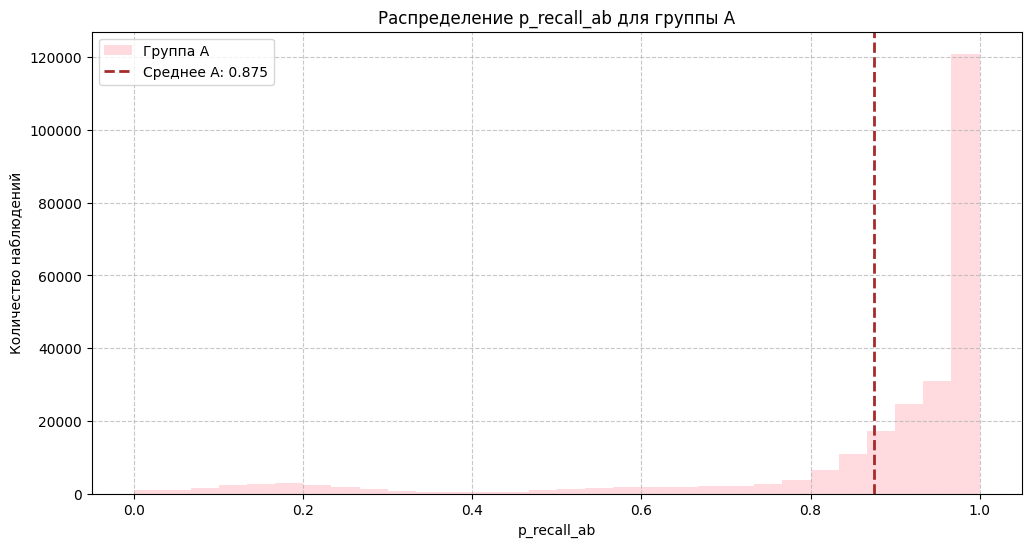

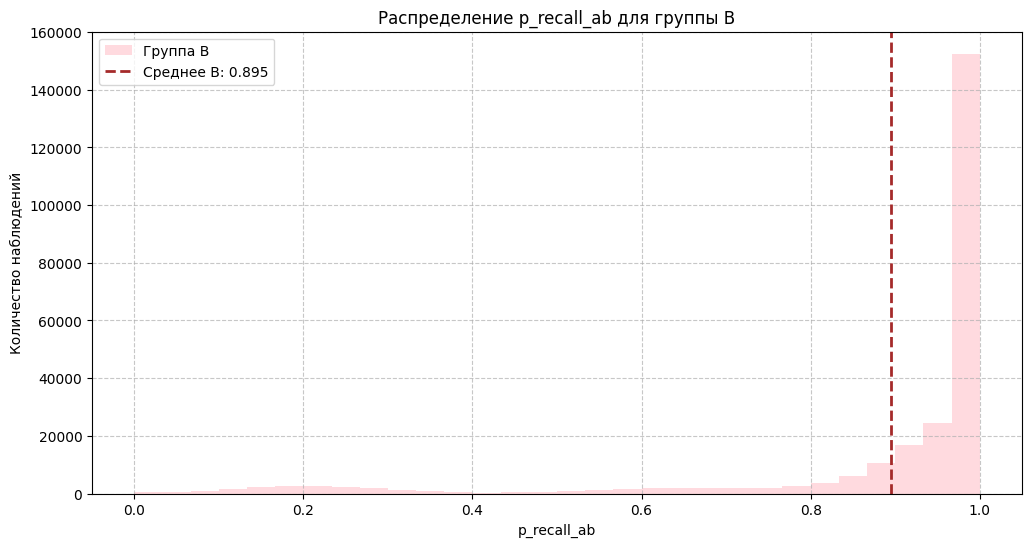

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

#Создаем DataFrame
duolingo_df = pd.read_csv('/Users/arinarogovets/Yandex.Disk.localized/Школа 21/Datasets /duolingo.csv')

#Задаем группы 
group_a = duolingo_df[duolingo_df['experiment_group'] == 'A']['p_recall_ab']
group_b = duolingo_df[duolingo_df['experiment_group'] == 'B']['p_recall_ab']
#Выводим количество записей в каждой группе 
print("="*70)
print("Количество записей в группе A:", len(group_a))
print("Количество записей в группе B:", len(group_b))
# Проверка баланса групп
print("="*70)
if len(group_a) == len(group_b):
    print("Группы сбалансированы по размеру")
else:
    print("Группы разного размера — это стоит учесть при интерпретации результатов теста")
#Проводим t-test
t_stat, p_value = ttest_ind(group_a, group_b, equal_var=False)
print("="*70)
print(f"Результаты t-теста:")
print(f"  • t-статистика: {t_stat:.6f}")
print(f"  • p-value: {p_value:.10f}")
print(f"  • Порог значимости (alpha): 0.05")
#Интерпретация результата
print("="*70)
print("Интерпретация результата:")
alpha = 0.05

if p_value < alpha:
    print("""Разница статистически значима (p-value < 0.05).
          Высока вероятность, что различие между группами не случайно.""")
else:
    print("""Разница НЕ является статистически значимой (p-value >= 0.05).
          Различие между группами может быть случайным.""")
    
if t_stat < 0:
    print("""Отрицательное значение t-статистики говорит о том, 
      что группа А имеет меньшее среднее значение, чем группа B.""")
elif t_stat > 0:
    print("""Положительное значение t-статистики говорит о том, 
      что группа B имеет меньшее среднее значение, чем группа A.""")
else:
    print("""Средние значениясравниваемых групп совпадают.""")

#Считаем абсолютную и относительную разницу 
mean_a = np.mean(group_a)
mean_b = np.mean(group_b)
abs_diff = mean_b - mean_a
rel_diff = (abs_diff / mean_a) * 100
print("="*70)
print("Размер эффекта:")
print(f"Среднее группы A: {mean_a:.6f}")
print(f"Среднее группы B: {mean_b:.6f}")
print(f"  • Абсолютная разница: {abs_diff:+.6f} ")
print(f"  • Относительная разница: {rel_diff:+.4f}%")

#Оценка величины эффекта
print("="*70)
if rel_diff < 5:
    effect_size = "малый"
elif rel_diff <= 15:
    effect_size = "умеренный"
else:
    effect_size = "большой"
print(f"""Поскольку разница составляет {rel_diff:+.2f}%,
      эффект стоит оценивать как {effect_size}.""")
#Итоговый вывод
print("="*70)
print("Итоговый вывод:")
if mean_b > mean_a:
    print("""Лучший результат показывает группа B, та,
      в которой была применена стратегия.""")
elif mean_a > mean_b:
    print("""Лучший результат показывает группа A, та,
      в которой НЕ была применена стратегия.""")
else:
    print("""Результат в сравниваемых группах одинаковый.""")


if p_value < alpha:
    print("Результату можно доверять: различия статистически значимы.")
else:
    print("Результат нельзя считать надежным: различия могут быть случайными.")


#Строим гистограммы
#Гистограмма группы А
plt.figure(figsize=(12, 6))
plt.hist(group_a, bins=30, alpha=0.5, label = "Группа А", color='lightpink')

plt.axvline(mean_a, color='brown', linestyle='--', linewidth=2, label=f'Среднее A: {mean_a:.3f}')

# Оформление графика
plt.title("Распределение p_recall_ab для группы А")
plt.xlabel("p_recall_ab")
plt.ylabel("Количество наблюдений")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

#Гистограмма группы B
plt.figure(figsize=(12, 6))
plt.hist(group_b, bins=30, alpha=0.5, label = "Группа B", color='lightpink')

plt.axvline(mean_b, color='brown', linestyle='dashed', linewidth=2, label=f'Среднее B: {mean_b:.3f}')

# Оформление графика
plt.title("Распределение p_recall_ab для группы B")
plt.xlabel("p_recall_ab")
plt.ylabel("Количество наблюдений")
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()


plt.show()

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency

#Создаем DataFrame
duolingo_df = pd.read_csv('/Users/arinarogovets/Yandex.Disk.localized/Школа 21/Datasets /duolingo.csv')

#Задаем группы 
group_a = duolingo_df[duolingo_df['experiment_group'] == 'A']['p_recall_ab']
group_b = duolingo_df[duolingo_df['experiment_group'] == 'B']['p_recall_ab']

#Считаем конверсию
conversion_a = duolingo_df[duolingo_df['experiment_group'] == 'A']['retention_7d'].mean()
conversion_b = duolingo_df[duolingo_df['experiment_group'] == 'B']['retention_7d'].mean()

print("="*70)
print(f"Конверсия в группе А:{conversion_a * 100:.2f}%")
print(f"Конверсия в группе B:{conversion_b * 100:.2f}%")

#Создаем таблицу сопряженности
cross_table = pd.crosstab(duolingo_df['experiment_group'], duolingo_df['retention_7d'])
print("="*70)
print("Таблица сопряженности:")
print(cross_table)
#Хи-квадрат тест
chi2_stat, p_value, dof, expected = chi2_contingency(cross_table)
print("="*70)
print("Результаты Хи-квадрат теста:")
print(f"  • Статистика Хи-квадрат: {chi2_stat:.4f}")
print(f"  • p-value: {p_value:.6f}")
print(f"  • Степени свободы: {dof}")

#Оцениваем p_value
print("="*70)
alpha = 0.05
print("Интерпретация результата:")
if p_value < alpha:
    print("Разница в конверсии статистически значима (p-value < 0.05).")
else:
    print("азница в конверсии НЕ является статистически значимой (p-value >= 0.05).")

#Итоговый вывод
print("="*70)
print("Итоговый вывод:")
if p_value < alpha:
    if conversion_b > conversion_a:
        print("Рекомендуем внедрить версию B.")
    else:
        print("Рекомендуем доработать версию B.")
else:
    print("Недостаточно данных для вывода, протестируем ещё раз.")


Конверсия в группе А:64.65%
Конверсия в группе B:67.88%
Таблица сопряженности:
retention_7d          0       1
experiment_group               
A                 88539  161890
B                 80162  169409
Результаты Хи-квадрат теста:
  • Статистика Хи-квадрат: 584.9997
  • p-value: 0.000000
  • Степени свободы: 1
Интерпретация результата:
Разница в конверсии статистически значима (p-value < 0.05).
Итоговый вывод:
Рекомендуем внедрить версию B.
